analysis -> feature engineering -> model

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [69]:
pd.set_option('display.max_columns',None)

In [70]:
df = pd.read_csv('E:\credit_card_fraud\creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [71]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [72]:
print('Missing values in each column:')
print(df.isnull().sum())
num_duplicates = df.duplicated().sum()
print('Number of duplicate rows:', num_duplicates)


Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Number of duplicate rows: 1081


In [73]:
corr = df[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class']].corr()


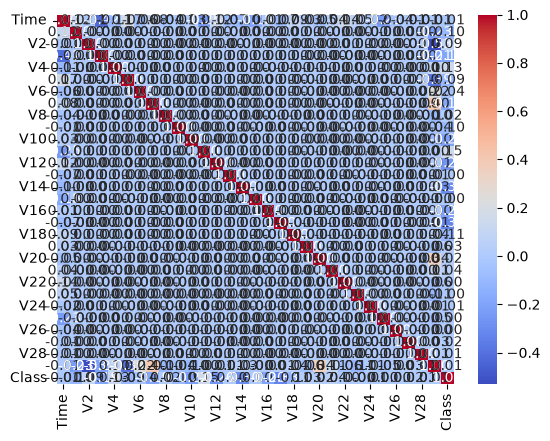

In [74]:
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f')
plt.show()

<Figure size 800x500 with 0 Axes>

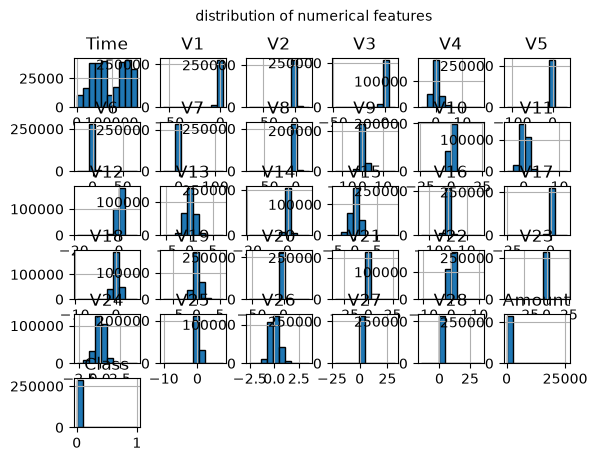

In [75]:
plt.figure(figsize=(8,5))
df[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class']].hist(bins=10, edgecolor = 'black')
plt.suptitle('distribution of numerical features', fontsize = 10)
plt.show()

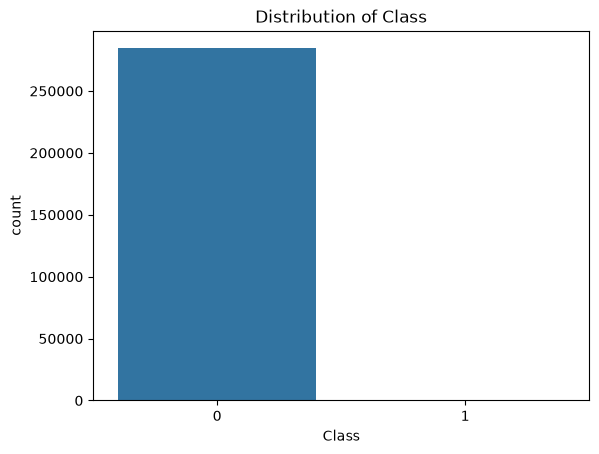

In [76]:
sns.countplot(x='Class', data= df)
plt.title('Distribution of Class')
plt.show()

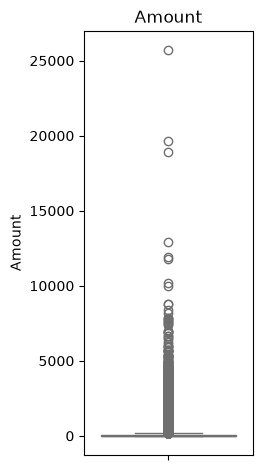

In [77]:
for i, col in enumerate(['Amount']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [78]:
# z score outlier detection
from scipy.stats import zscore, norm
alpha = 0.05
confidence = 1 - alpha
critical_z = norm.ppf(1 - alpha/2)
print(critical_z)



1.959963984540054


In [79]:
df['Z_score'] = zscore(df['Amount'])
df_filtered = df[df["Z_score"].abs() <= critical_z]

In [80]:
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()
# df_filtered[[ 'Amount']] = scaler.fit_transform(df_filtered[['Amount']])

In [81]:
df_filtered.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Z_score'],
      dtype='str')

In [82]:
features = df_filtered.drop(columns=['Time','Z_score', 'Class'])
features.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')

In [83]:
from sklearn.model_selection import train_test_split
x = features
y = df_filtered['Class']
X_train, X_test, y_train, y_test = train_test_split( x,y, test_size=0.2,random_state=42, stratify=y)

In [84]:
# from imblearn.under_sampling import RandomUnderSampler
# rus = RandomUnderSampler(random_state=42)
# X_train_under, y_train_under=rus.fit_resample(X_train, y_train)

In [85]:
print(y_train.value_counts())

Class
0    221498
1       370
Name: count, dtype: int64


In [86]:
# print(y_train_under.value_counts())

In [87]:
# sns.countplot(x=y_train_under)
# plt.title('class distribution after random undersampling')
# plt.show()

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold
kf = KFold(n_splits=5, shuffle=False, random_state=None)
param_grid ={
    'C':10.0 **np.arange(-2,3),
    'penalty':['l2'],
    # 'class_weight':['balanced']
}
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv = kf,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
y_pred_lr = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]


c:\Users\navin\miniconda3\envs\machinelearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\navin\miniconda3\envs\machinelearning\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

In [94]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score,confusion_matrix, classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55374
           1       0.85      0.69      0.76        93

    accuracy                           1.00     55467
   macro avg       0.93      0.84      0.88     55467
weighted avg       1.00      1.00      1.00     55467



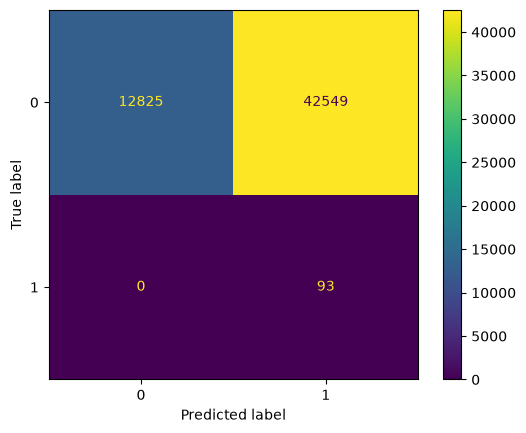

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

In [91]:
def calculate_iv(df, feature, target, bins=10):
    data = df[[feature, target]].copy()

    data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')

    grouped = data.groupby('bin', as_index=False)

    iv_df = pd.DataFrame()
    iv_df['bin'] = [str(b) for b in grouped.groups.keys()]
    iv_df['total'] = grouped.count()[target].values
    iv_df['events'] = grouped.sum()[target].values # Fraud (Class = 1)
    iv_df['non_events'] = iv_df['total'] - iv_df['events'] # Legit (Class = 0)

    total_events = iv_df['events'].sum()
    total_non_events = iv_df['non_events'].sum()

    iv_df['pct_events'] = (iv_df['events'] + 0.0001) / (total_events + 0.0001)
    iv_df['pct_non_events'] = (iv_df['non_events'] + 0.0001) / (total_non_events + 0.0001)

    iv_df['WOE'] = np.log(iv_df['pct_non_events'] / iv_df['pct_events'])
    iv_df['IV'] = (iv_df['pct_non_events'] - iv_df['pct_events']) * iv_df['WOE']

    total_iv = iv_df['IV'].sum()

    return total_iv, iv_df

In [92]:
calculate_iv(df_filtered, feature = 'V1',target = 'Class', bins=10)

(np.float64(1.556732711272242),
                              bin  total  events  non_events  pct_events  \
 0  (-46.855999999999995, -1.815]  27734     261       27473    0.563715   
 1               (-1.815, -1.095]  27733      46       27687    0.099352   
 2               (-1.095, -0.724]  27734      18       27716    0.038877   
 3               (-0.724, -0.406]  27733      19       27714    0.041037   
 4               (-0.406, 0.0508]  27734      17       27717    0.036717   
 5                (0.0508, 1.066]  27733      52       27681    0.112311   
 6                 (1.066, 1.236]  27733      29       27704    0.062635   
 7                 (1.236, 1.745]  27734       8       27726    0.017279   
 8                 (1.745, 2.019]  27734      11       27723    0.023758   
 9                 (2.019, 2.455]  27733       2       27731    0.004320   
 
    pct_non_events       WOE        IV  
 0        0.099226 -1.737145  0.806884  
 1        0.099999  0.006491  0.000004  
 2     